In [2]:
#Install libraries
!pip install shap tensorflow

In [3]:
#Import libraries
import json
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import shap
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#load dataset
model=ResNet50(weights='imagenet')
X,y=shap.datasets.imagenet50()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [5]:
#Scaling the Images

#Assuming X[8] contain integer data that needs to be scaled to the range [0, 255]

X=np.clip(X,0,255).astype(np.uint8)

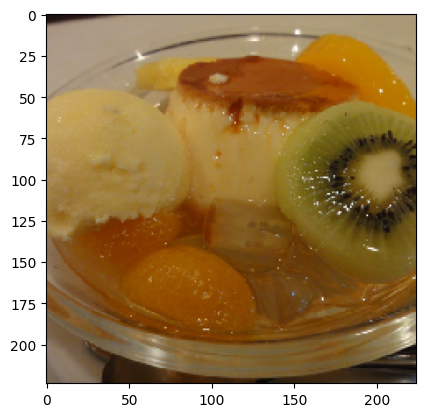

In [6]:
#Display some sample images
plt.imshow(X[20])

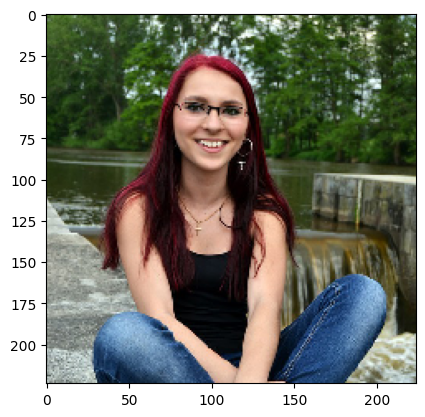

In [7]:
plt.imshow(X[25])

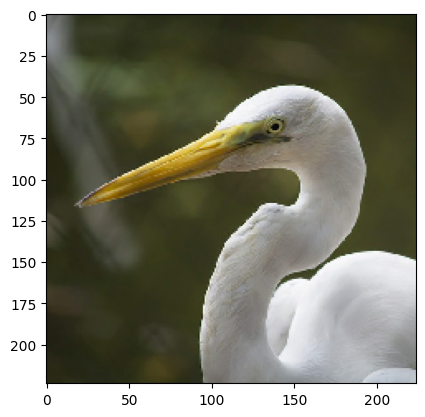

In [8]:
plt.imshow(X[1])

In [9]:
print(X.shape)

(50, 224, 224, 3)


Imagenet class names

In [10]:
url="https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
with open(shap.datasets.cache(url)) as file:
  class_names=[v[1] for v in json.load(file).values()]

In [11]:
print("Number of ImageNet classes:", len(class_names))
print("Class names:", class_names)

Number of ImageNet classes: 1000
Class names: ['tench', 'goldfish', 'great_white_shark', 'tiger_shark', 'hammerhead', 'electric_ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house_finch', 'junco', 'indigo_bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water_ouzel', 'kite', 'bald_eagle', 'vulture', 'great_grey_owl', 'European_fire_salamander', 'common_newt', 'eft', 'spotted_salamander', 'axolotl', 'bullfrog', 'tree_frog', 'tailed_frog', 'loggerhead', 'leatherback_turtle', 'mud_turtle', 'terrapin', 'box_turtle', 'banded_gecko', 'common_iguana', 'American_chameleon', 'whiptail', 'agama', 'frilled_lizard', 'alligator_lizard', 'Gila_monster', 'green_lizard', 'African_chameleon', 'Komodo_dragon', 'African_crocodile', 'American_alligator', 'triceratops', 'thunder_snake', 'ringneck_snake', 'hognose_snake', 'green_snake', 'king_snake', 'garter_snake', 'water_snake', 'vine_snake', 'night_snake', 'boa_constrictor', 'rock_python', 'Indian_cobra', 'green_mamba'

Define SHAP explainer

In [12]:
def f(x):
  tmp=x.copy()
  preprocess_input(tmp)
  return model(tmp)

# define a masker that is used to mask out partitions of the input image
masker=shap.maskers.Image('inpaint_telea', X[0].shape)

#create an explainer with model and image masker
explainer=shap.Explainer(f, masker, output_names=class_names)

#here we explain two images using 100 evaluations of the underlying model to estimate the SHAP values
shap_values=explainer(X[1:3], max_evals=100, batch_size=50, outputs=shap.Explanation.argsort.flip[:4])

  0%|          | 0/98 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [00:16,  8.08s/it]


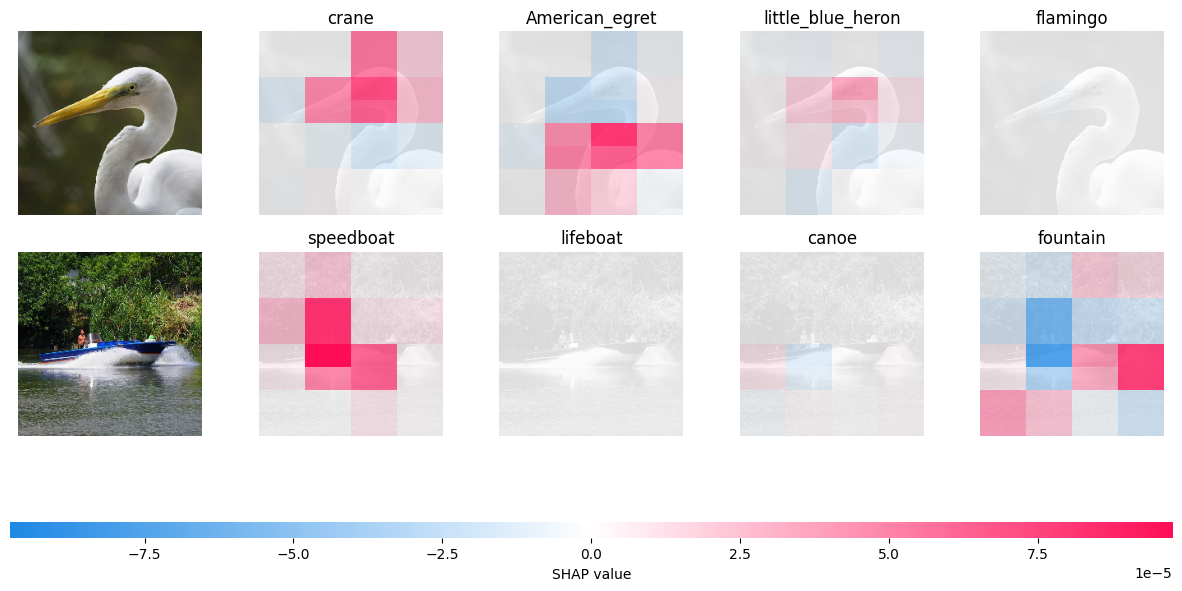

In [13]:
#output with shap values
shap.image_plot(shap_values)

In [19]:
def f(x):
  tmp=x.copy()
  preprocess_input(tmp)
  return model(tmp)

# define a masker that is used to mask out partitions of the input image
masker=shap.maskers.Image('blur(128,128)', X[0].shape)

#create an explainer with model and image masker
explainer=shap.Explainer(f, masker, output_names=class_names)

#here we explain two images using 100 evaluations of the underlying model to estimate the SHAP values
shap_values=explainer(X[1:3], max_evals=500, batch_size=50, outputs=shap.Explanation.argsort.flip[:4])

Plot SHAP output

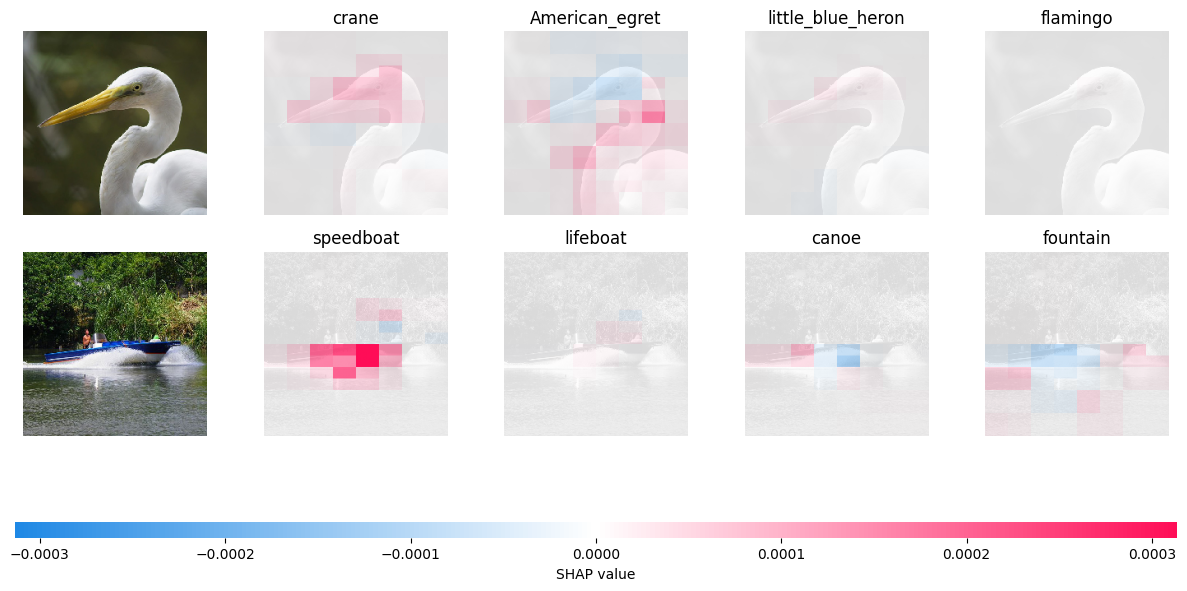

In [20]:
#output with shap values

shap.image_plot(shap_values)